In [2]:
#skorch : pytorch를 쉽게 구현할 수 있는 라이브러리
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
X_train = X_train.reshape(-1,784)  #28*28pixel 을 2차원으로 변경
X_test = X_test.reshape(-1,784)
X_train = X_train/255.  #. 실수형 지정
X_test = X_test/255.

In [4]:
import torch
# 넘파이를 텐서로 가져오기
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train.astype('int32')).long()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test.astype('int32')).long()
print(X_train.shape)
print(X_test.shape)

torch.Size([60000, 784])
torch.Size([10000, 784])


In [5]:
import torch.nn as nn
import torch.nn.functional as F
#Class 현재(super clss:상위 클래스)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=-1) #-1 마지막 차원

model=Net()

In [6]:
##############################
# pip install skorch(사이코치)
from skorch import NeuralNetClassifier
                          #신경망, 에폭, 학습률
net = NeuralNetClassifier(Net,max_epochs=20,lr=0.1)
net.fit(X_train, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6439       0.8973        0.3543  0.9399
      2        0.3210       0.9142        0.2940  0.8806
      3        0.2714       0.9260        0.2551  1.0315
      4        0.2340       0.9344        0.2244  0.8480
      5        0.2046       0.9412        0.2010  0.9396
      6        0.1816       0.9472        0.1827  0.9995
      7        0.1631       0.9511        0.1677  1.0557
      8        0.1479       0.9553        0.1561  1.0373
      9        0.1352       0.9579        0.1464  0.9257
     10        0.1245       0.9591        0.1383  0.9592
     11        0.1153       0.9607        0.1318  1.0450
     12        0.1072       0.9623        0.1261  0.9838
     13        0.1001       0.9637        0.1212  1.0284
     14        0.0938       0.9651        0.1168  0.9508
     15        0.0881       0.9658        0.1130  0.9198
     16        0.0830       0.9

,module,<class '__main__.Net'>
,criterion,<class 'torch...loss.NLLLoss'>
,train_split,<skorch.datas...0019B808D2750>
,classes,None
,optimizer,<class 'torch.optim.sgd.SGD'>
,lr,0.1
,max_epochs,20
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


In [7]:
##############################
import numpy as np
pred = net.predict(X_test)
y_test = y_test.numpy()
accuracy = np.mean(pred == y_test)
accuracy

np.float64(0.9735)

In [8]:
##############################
from torchinfo import summary
summary(model, input_size=(100,784))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [100, 10]                 --
├─Linear: 1-1                            [100, 128]                100,480
├─Linear: 1-2                            [100, 10]                 1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 10.18
Input size (MB): 0.31
Forward/backward pass size (MB): 0.11
Params size (MB): 0.41
Estimated Total Size (MB): 0.83

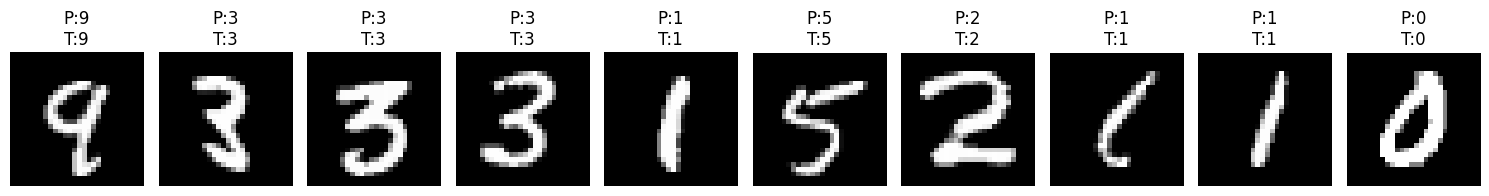

In [9]:
##############################
import matplotlib.pyplot as plt

num_images = 10
sample_idx = np.random.choice(len(X_test), num_images, replace=False)

fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
for i, idx in enumerate(sample_idx):
    img = X_test[idx].reshape(28, 28).numpy()  # 784 → 28x28
    pred_label = pred[idx]
    true_label = y_test[idx]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"P:{pred_label}\nT:{true_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()